--- Kết quả Đánh giá trên tập Test ---
RNN Model    -> MSE: 0.00593 | MAE: 0.06524
Naive Model  -> MSE: 0.00693


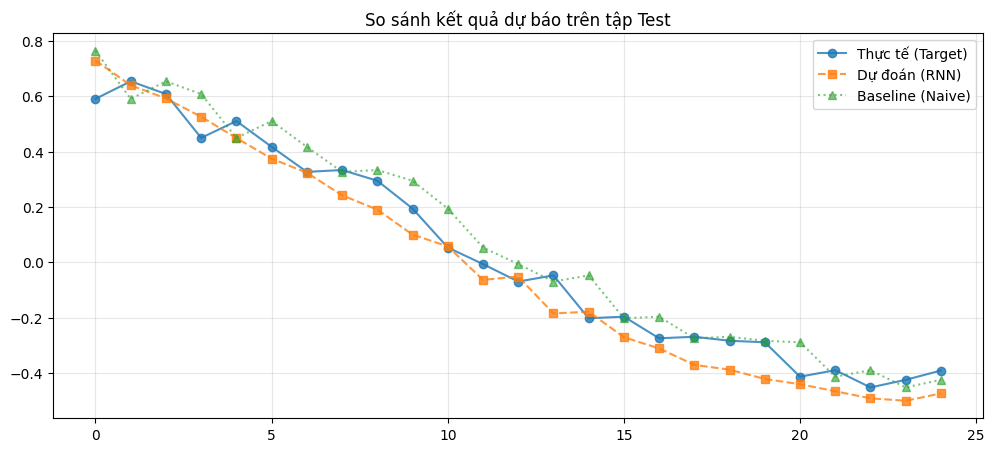

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# 0. Khởi tạo dữ liệu gốc từ đề bài
np.random.seed(42)
torch.manual_seed(42)

time_steps = 300
t = np.linspace(0, 30, time_steps)
feature_1 = np.sin(t)
feature_2 = np.cos(0.5 * t)
feature_3 = 0.05 * t + 0.1 * np.random.randn(time_steps)
target = 0.5 * feature_1 + 0.3 * feature_2 + 0.2 * feature_3 + 0.05 * np.random.randn(time_steps)

df = pd.DataFrame({
    'feature_1': feature_1,
    'feature_2': feature_2,
    'feature_3': feature_3,
    'target': target,
})

# ----------------------------------------------------
# PHẦN A — TIỀN XỬ LÝ (Tránh Data Leakage)
# ----------------------------------------------------
# Chia tỉ lệ 70% train / 15% val / 15% test
train_idx = int(0.7 * len(df))
val_idx = int(0.85 * len(df))

train_df = df.iloc[:train_idx]
val_df = df.iloc[train_idx:val_idx]
test_df = df.iloc[val_idx:]

# Fit scaler TRÊN TẬP TRAIN và biến đổi val/test
scaler_features = MinMaxScaler()
scaler_target = MinMaxScaler()

# Tách features và target
X_train_raw = train_df[['feature_1', 'feature_2', 'feature_3']].values
y_train_raw = train_df[['target']].values

X_val_raw = val_df[['feature_1', 'feature_2', 'feature_3']].values
y_val_raw = val_df[['target']].values

X_test_raw = test_df[['feature_1', 'feature_2', 'feature_3']].values
y_test_raw = test_df[['target']].values

# Chuẩn hóa
X_train_scaled = scaler_features.fit_transform(X_train_raw)
y_train_scaled = scaler_target.fit_transform(y_train_raw)

X_val_scaled = scaler_features.transform(X_val_raw)
y_val_scaled = scaler_target.transform(y_val_raw)

X_test_scaled = scaler_features.transform(X_test_raw)
y_test_scaled = scaler_target.transform(y_test_raw)

# Hàm tạo cửa sổ trượt (sliding window)
def create_multivariate_sequences(X_data, y_data, seq_length):
    X, y = [], []
    for i in range(len(X_data) - seq_length):
        X.append(X_data[i : i + seq_length])
        y.append(y_data[i + seq_length])
    return torch.FloatTensor(np.array(X)), torch.FloatTensor(np.array(y))

seq_length = 20
X_train_t, y_train_t = create_multivariate_sequences(X_train_scaled, y_train_scaled, seq_length)
X_val_t, y_val_t = create_multivariate_sequences(X_val_scaled, y_val_scaled, seq_length)
X_test_t, y_test_t = create_multivariate_sequences(X_test_scaled, y_test_scaled, seq_length)

# DataLoader
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=16, shuffle=True)

# ----------------------------------------------------
# PHẦN B — ĐỊNH NGHĨA VÀ HUẤN LUYỆN MÔ HÌNH
# ----------------------------------------------------
class MultivariateRNN(nn.Module):
    def __init__(self, input_size=3, hidden_size=32, output_size=1):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :]) # Lấy trạng thái ẩn ở bước cuối cùng
        return out

model = MultivariateRNN(input_size=3, hidden_size=32, output_size=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

num_epochs = 150
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)

    epoch_train_loss = running_loss / len(X_train_t)
    train_losses.append(epoch_train_loss)


    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_t)
        epoch_val_loss = criterion(val_outputs, y_val_t).item()
        val_losses.append(epoch_val_loss)


model.eval()
with torch.no_grad():
    pred_scaled = model(X_test_t).numpy()


pred_unscaled = scaler_target.inverse_transform(pred_scaled).squeeze()
truth_unscaled = y_test_raw[seq_length:].squeeze()

naive_pred_unscaled = y_test_raw[seq_length-1 : -1].squeeze()

mse_rnn = np.mean((pred_unscaled - truth_unscaled) ** 2)
mae_rnn = np.mean(np.abs(pred_unscaled - truth_unscaled))
mse_naive = np.mean((naive_pred_unscaled - truth_unscaled) ** 2)

print(f"--- Kết quả Đánh giá trên tập Test ---")
print(f"RNN Model    -> MSE: {mse_rnn:.5f} | MAE: {mae_rnn:.5f}")
print(f"Naive Model  -> MSE: {mse_naive:.5f}")

plt.figure(figsize=(12, 5))
plt.plot(truth_unscaled, 'o-', label='Thực tế (Target)', alpha=0.8)
plt.plot(pred_unscaled, 's--', label='Dự đoán (RNN)', alpha=0.8)
plt.plot(naive_pred_unscaled, '^:', label='Baseline (Naive)', alpha=0.6)
plt.title('So sánh kết quả dự báo trên tập Test')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

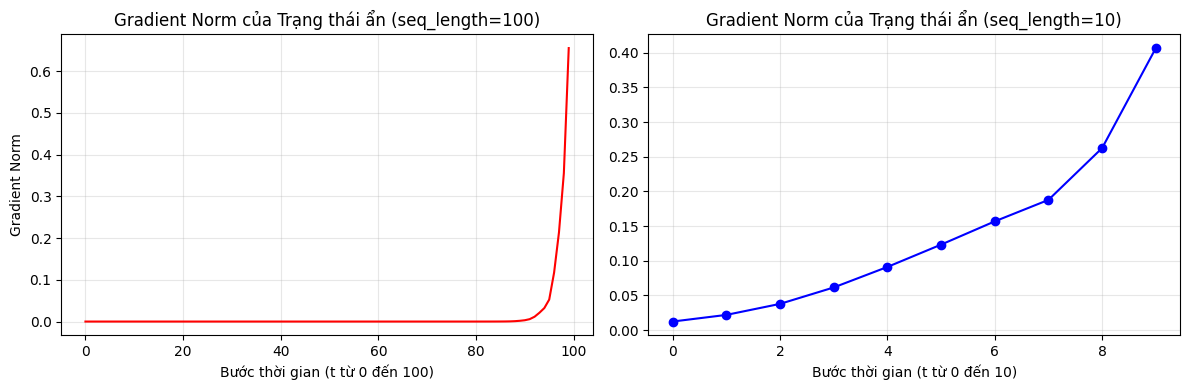

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
torch.manual_seed(42)

# 1. Sinh dữ liệu chuỗi sin dài
time_steps = 500
t_long = np.linspace(0, 100, time_steps)
data_long = np.sin(t_long)

# Hàm lấy 1 mẫu duy nhất có độ dài seq_length
def get_single_sequence(data, seq_length):
    X = data[:seq_length]
    y = data[seq_length]
    return torch.FloatTensor(X).view(1, seq_length, 1), torch.FloatTensor([y]).view(1, 1) # Ensure y has shape (1, 1)

# 2. Định nghĩa hàm phân tích Gradient Norm theo từng bước thời gian
def analyze_gradient_flow(seq_length):
    X, y = get_single_sequence(data_long, seq_length)

    # Khởi tạo RNN đơn giản
    rnn_cell = nn.RNN(input_size=1, hidden_size=8, batch_first=True)
    fc = nn.Linear(8, 1)

    # Initialize h_t for the first step (h_0). It must require grad to be tracked.
    # The shape for RNN's initial hidden state `h_0` is (num_layers * num_directions, batch_size, hidden_size)
    # For this simple RNN: (1, 1, 8)
    h_t_initial = torch.zeros(1, 1, 8, requires_grad=True)
    hidden_states_for_grad = [] # This will store the actual h_t tensors at each step

    current_h_state = h_t_initial # Start with h_0

    # Run through the sequence, keeping track of intermediate hidden states
    for t_step in range(seq_length):
        x_t = X[:, t_step:t_step+1, :] # Input x_t for current step, shape (1, 1, 1)

        out_t, h_t_next = rnn_cell(x_t, current_h_state)

        # Ensure gradients are retained for this intermediate hidden state
        h_t_next.retain_grad()
        hidden_states_for_grad.append(h_t_next)

        current_h_state = h_t_next # Update hidden state for the next iteration

    # final_output takes the last hidden state and passes it through a linear layer
    # current_h_state is (1, 1, 8). fc expects (batch_size, hidden_size), so we squeeze.
    final_output = fc(current_h_state.squeeze(0))

    loss = nn.MSELoss()(final_output, y)

    # Perform the backward pass once.
    # This will compute gradients for all tensors in the graph that require_grad=True
    # and for which retain_grad() was called.
    loss.backward(retain_graph=True) # retain_graph=True for safety, though not strictly needed for a single backward call if we're just reading .grad

    # Retrieve the norms of the gradients
    grads_norm = []
    for t_step in range(seq_length):
        h_state = hidden_states_for_grad[t_step]
        if h_state.grad is not None:
            grads_norm.append(torch.norm(h_state.grad).item())
        else:
            # This indicates an issue. All h_states from the RNN should have gradients
            # if they are part of the graph and retain_grad() was called.
            print(f"Warning: Gradient for h_t at step {t_step} is None.")
            grads_norm.append(0.0) # Append 0 if grad is None, for plotting purposes.

    return grads_norm

# 3. Chạy thí nghiệm và vẽ đồ thị so sánh seq_length = 100 và seq_length = 10
grads_100 = analyze_gradient_flow(seq_length=100)
grads_10 = analyze_gradient_flow(seq_length=10)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(grads_100, color='red')
plt.title('Gradient Norm của Trạng thái ẩn (seq_length=100)')
plt.xlabel('Bước thời gian (t từ 0 đến 100)')
plt.ylabel('Gradient Norm')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(grads_10, color='blue', marker='o')
plt.title('Gradient Norm của Trạng thái ẩn (seq_length=10)')
plt.xlabel('Bước thời gian (t từ 0 đến 10)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [1]:
import torch
import torch.nn as nn
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

# 1. Tái tạo dữ liệu tương tự bài lab
time_steps = 200
x = np.linspace(0, 40, time_steps)
data = np.sin(x) + 0.1 * np.random.randn(time_steps)
data = (data - data.min()) / (data.max() - data.min())
data = torch.FloatTensor(data).unsqueeze(1)

seq_length = 10
X, y = [], []
for i in range(len(data) - seq_length):
    X.append(data[i : i + seq_length])
    y.append(data[i + seq_length])
X, y = torch.stack(X), torch.stack(y)

train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# ----------------------------------------------------
# ĐỊNH NGHĨA 2 MÔ HÌNH: ANN và RNN
# ----------------------------------------------------
class ANN_Model(nn.Module):
    def __init__(self, input_dim=10, hidden_dim=20, output_dim=1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x shape ban đầu: (batch, seq_len, 1) -> flatten thành (batch, seq_len)
        x = x.view(x.size(0), -1)
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

class RNN_Model(nn.Module):
    def __init__(self, input_size=1, hidden_size=20, output_size=1):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

# Khởi tạo mô hình
ann = ANN_Model()
rnn = RNN_Model()

# Hàm Train mẫu đơn giản nhanh chóng
def train_simple_model(model, X_tr, y_tr, epochs=100):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(X_tr)
        loss = criterion(out, y_tr)
        loss.backward()
        optimizer.step()

train_simple_model(ann, X_train, y_train)
train_simple_model(rnn, X_train, y_train)
ann.eval()
rnn.eval()

with torch.no_grad():
    pred_ann = ann(X_test).squeeze().numpy()
    pred_rnn = rnn(X_test).squeeze().numpy()

truth = y_test.squeeze().numpy()
pred_naive = X_test[:, -1, 0].numpy() # Giá trị cuối cùng của cửa sổ đầu vào

# Tính toán MSE
mse_ann = np.mean((pred_ann - truth) ** 2)
mse_rnn = np.mean((pred_rnn - truth) ** 2)
mse_naive = np.mean((pred_naive - truth) ** 2)

# Đếm tham số
params_ann = sum(p.numel() for p in ann.parameters())
params_rnn = sum(p.numel() for p in rnn.parameters())

print(f"1. RNN Model    -> One-step MSE: {mse_rnn:.5f} | Số lượng tham số: {params_rnn}")
print(f"2. ANN Model    -> One-step MSE: {mse_ann:.5f} | Số lượng tham số: {params_ann}")
print(f"3. Baseline Naive -> One-step MSE: {mse_naive:.5f} | Số lượng tham số: 0")

1. RNN Model    -> One-step MSE: 0.00307 | Số lượng tham số: 481
2. ANN Model    -> One-step MSE: 0.00217 | Số lượng tham số: 241
3. Baseline Naive -> One-step MSE: 0.00600 | Số lượng tham số: 0
